# PrimetradeAI Data Science Assignment

## Importing Required Libraries

The analysis begins by importing the necessary Python libraries for data manipulation, data visualization, and exploratory data analysis.

- **Pandas** is used for data loading, cleaning, transformation, and analysis.
- **NumPy** is used for numerical computations.
- **Matplotlib** is used for creating visualizations and charts.
- **Seaborn** is used to generate more informative and visually appealing statistical plots.

Additionally, the display settings are configured to show all columns in the dataset, making data exploration easier during analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Loading the Datasets

In this step, both datasets are loaded into Pandas DataFrames for analysis.

### Datasets Used

**1. Historical Trader Data**
- Contains detailed trading activity from Hyperliquid traders.
- Includes information such as trade size, execution price, trade direction, fees, and realized profit/loss (Closed PnL).

**2. Bitcoin Fear & Greed Index**
- Contains daily market sentiment classifications.
- Sentiment categories include Fear, Extreme Fear, Greed, Extreme Greed, and Neutral.

These datasets form the foundation of the analysis and will later be combined to investigate how market sentiment influences trader behavior and profitability.

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

## Initial Data Exploration

Before performing any analysis, it is important to understand the structure and contents of the datasets.

In this step:

- The first few rows of the trader dataset are displayed using `head()`.
- Dataset metadata is examined using `info()`.
- Column names, data types, and missing values are reviewed.
- The overall size and structure of the dataset are validated.

This exploratory step helps identify potential data quality issues and provides a better understanding of the available features for further analysis.

In [3]:
print("TRADES DATA")
print(trades.head())

print("\nTRADES INFO")
print(trades.info())

TRADES DATA
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

### Exploring the Market Sentiment Dataset

The Fear & Greed Index dataset is examined to understand its structure, available features, and sentiment categories.

This step helps verify:

- The date format used for sentiment records.
- The sentiment classification labels available in the dataset.
- Data types of each column.
- The completeness and quality of the sentiment data.

Understanding the sentiment dataset is essential because it will later be merged with the trader dataset to analyze the impact of market sentiment on trading performance.

In [4]:
print("\nSENTIMENT DATA")
print(sentiment.head())

print("\nSENTIMENT INFO")
print(sentiment.info())


SENTIMENT DATA
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

SENTIMENT INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


### Understanding Dataset Features

To gain a better understanding of the available variables, the column names of both datasets are examined.

This step helps to:

- Identify relevant features for analysis.
- Understand the information available in each dataset.
- Select appropriate columns for data cleaning, transformation, and merging.
- Determine which variables can be used to evaluate trader performance and market sentiment.

Understanding the dataset schema is a critical step before performing feature engineering and analytical modeling.

In [5]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


### Observation

The trader dataset contains information related to trade execution, trade size, trading direction, fees, and realized profit/loss (Closed PnL).

The sentiment dataset contains daily market sentiment scores and classifications such as Fear, Greed, Extreme Fear, Extreme Greed, and Neutral.

The common feature required for integration between the two datasets is the date field, which will be standardized and used for merging in the next step.

## Data Preprocessing and Date Standardization

Before combining the datasets, the date fields must be converted into a consistent format.

The trader dataset stores date and time information in the **Timestamp IST** column, while the sentiment dataset stores dates in a separate **date** column. To enable accurate integration, both columns are converted into a standardized date format.

This preprocessing step ensures that:

- Dates are represented consistently across both datasets.
- Time information is removed where not required.
- Records from both datasets can be accurately matched on the same trading day.
- Future analysis correctly associates each trade with the corresponding market sentiment.

The standardized **Date** column will be used as the primary key for merging the datasets in the next step.

In [6]:
# Trade dataset date

trades['Date'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

# Sentiment dataset date

sentiment['Date'] = pd.to_datetime(
    sentiment['date']
).dt.date

### Verification of Date Conversion

After standardizing the date fields, a quick validation is performed to ensure that the new **Date** columns have been created correctly and are ready for dataset integration.

### Verification of Date Standardization

To ensure successful data integration, the newly created **Date** columns are validated by comparing them with their original date fields.

This verification step confirms that:

- The original timestamp values have been converted correctly.
- The date extraction process has preserved the correct trading day.
- Both datasets now share a common date format suitable for merging.

Accurate date standardization is essential because all subsequent analyses depend on correctly matching trader activity with the corresponding market sentiment.

In [7]:
print(trades[['Timestamp IST','Date']].head())
print(sentiment[['date','Date']].head())

      Timestamp IST        Date
0  02-12-2024 22:50  2024-12-02
1  02-12-2024 22:50  2024-12-02
2  02-12-2024 22:50  2024-12-02
3  02-12-2024 22:50  2024-12-02
4  02-12-2024 22:50  2024-12-02
         date        Date
0  2018-02-01  2018-02-01
1  2018-02-02  2018-02-02
2  2018-02-03  2018-02-03
3  2018-02-04  2018-02-04
4  2018-02-05  2018-02-05


## Data Integration

To analyze the relationship between trader performance and market sentiment, the trader dataset was merged with the Fear & Greed Index dataset using the standardized **Date** column.

The merge operation associates each trade with the corresponding market sentiment recorded on the same day.

### Why This Step Is Important

This integration enables the analysis of:

- Trader profitability under different market sentiments.
- Trading activity during Fear, Greed, and Neutral market conditions.
- The impact of sentiment on trading behavior and performance.
- Patterns that can support sentiment-aware trading strategies.

A **left join** is used to preserve all trading records while enriching them with sentiment information from the Fear & Greed dataset.

In [8]:
merged = pd.merge(
    trades,
    sentiment[['Date','classification','value']],
    on='Date',
    how='left'
)

print("Shape:", merged.shape)

print("\nMissing Sentiments:")
print(merged['classification'].isnull().sum())

print("\nSample:")
print(
    merged[['Date','classification','Closed PnL']]
    .head()
)

Shape: (211224, 19)

Missing Sentiments:
6

Sample:
         Date classification  Closed PnL
0  2024-12-02  Extreme Greed         0.0
1  2024-12-02  Extreme Greed         0.0
2  2024-12-02  Extreme Greed         0.0
3  2024-12-02  Extreme Greed         0.0
4  2024-12-02  Extreme Greed         0.0


### Merge Validation

After merging the datasets, several validation checks are performed:

1. Verify the final dataset dimensions.
2. Check for missing sentiment values.
3. Inspect a sample of merged records.

The results indicate that sentiment information was successfully mapped to almost all trading records, confirming that the datasets were integrated correctly and are ready for exploratory analysis.

## Sentiment-Based Profitability Analysis

One of the primary objectives of this assignment is to understand how market sentiment influences trader profitability.

To achieve this, trading performance is analyzed across different sentiment categories using the **Closed Pn

In [9]:
sentiment_pnl = merged.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count','mean','sum','median']
).sort_values(
    by='mean',
    ascending=False
)

print(sentiment_pnl)

                count       mean           sum  median
classification                                        
Extreme Greed   39992  67.892861  2.715171e+06     0.0
Fear            61837  54.290400  3.357155e+06     0.0
Greed           50303  42.743559  2.150129e+06     0.0
Extreme Fear    21400  34.537862  7.391102e+05     0.0
Neutral         37686  34.307718  1.292921e+06     0.0


## Trading Activity Analysis Across Market Sentiments

In addition to profitability, it is important to understand how trader participation changes under different market conditions.

This analysis measures the number of trades executed within each sentiment category to identify periods of high and low trading activity.

### Objective

The goal is to answer the following questions:

- During which market sentiment are traders most active?
- Do traders participate more during Fear or Greed conditions?
- How does market sentiment influence trading behavior and engagement?

By analyzing trade frequency across sentiment categories, we can better understand how market psychology affects overall trading activity.

In [10]:
activity = merged['classification'].value_counts()

print(activity)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


### Key Findings

- **Fear** recorded the highest trading activity with **61,837 trades**.
- **Greed** was the second most active sentiment category with **50,303 trades**.
- **Extreme Fear** had the lowest trading activity among all sentiment categories.

### Interpretation

The results suggest that traders become more active during periods of market uncertainty and fear. Increased participation during Fear conditions may indicate that traders are attempting to capitalize on market volatility or perceived buying opportunities.

This finding highlights the strong influence of market sentiment on trader behavior and decision-making.

## BUY vs SELL Performance Analysis

To further understand trader behavior, profitability is analyzed separately for BUY and SELL trades across different market sentiment conditions.

This analysis helps determine whether trade direction influences performance and whether certain strategies are more effective under specific market sentiments.

### Objective

The analysis aims to answer the following questions:

- Do BUY trades perform better than SELL trades?
- How does market sentiment affect the profitability of BUY and SELL positions?
- Are traders more successful going long during Fear or taking profits during Greed?

By comparing average Closed PnL across trade directions and sentiment categories, we can identify behavioral patterns and potentially effective trading strategies.

In [11]:
buy_sell = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

print(buy_sell)

Side                  BUY        SELL
classification                       
Extreme Fear    34.114627   34.980106
Extreme Greed   10.498927  114.584643
Fear            63.927104   45.049641
Greed           25.002302   59.691091
Neutral         29.227429   39.456408


### Key Findings

- During **Fear** market conditions, BUY trades generated a higher average profit (**63.93**) compared to SELL trades (**45.05**).
- During **Greed** and **Extreme Greed**, SELL trades significantly outperformed BUY trades.
- The highest average profitability was observed in **SELL trades during Extreme Greed** (**114.58** average PnL).

### Interpretation

The results suggest that trader performance is strongly influenced by both market sentiment and trade direction.

During Fear periods, buying opportunities appear to be more profitable, possibly because traders accumulate assets at lower prices. In contrast, during Greed and Extreme Greed periods, SELL trades tend to perform better, indicating that profit-taking or short-selling strategies may be more effective when market optimism is high.

These findings highlight the importance of aligning trading strategies with prevailing market sentiment.

## Trade Size and Profitability Analysis

Trade size is an important factor that can significantly influence trading outcomes. To investigate this relationship, trades are categorized into four groups based on their USD value:

- Small
- Medium
- Large
- Very Large

The categories are created using quartile-based segmentation, ensuring that each group contains approximately the same number of trades.

### Objective

This analysis aims to answer the following questions:

- Does trade size impact profitability?
- Are larger trades associated with higher returns?
- How does trader performance change as capital exposure increases?

By comparing profitability across different trade size categories, we can better understand the relationship between position sizing and trading performance.

In [12]:
merged['Trade_Category'] = pd.qcut(
    merged['Size USD'],
    q=4,
    labels=['Small','Medium','Large','Very Large']
)

size_analysis = merged.groupby(
    'Trade_Category'
)['Closed PnL'].agg(
    ['count','mean','sum']
)

print(size_analysis)

                count        mean           sum
Trade_Category                                 
Small           52829    2.168210  1.145443e+05
Medium          52783    6.596610  3.481889e+05
Large           52806   22.015666  1.162559e+06
Very Large      52806  164.217447  8.671666e+06


C:\Users\ideal\AppData\Local\Temp\ipykernel_4940\1539215707.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_analysis = merged.groupby(


### Key Findings

- Average profitability increases consistently with trade size.
- Small trades generated an average profit of only **2.17** per trade.
- Very Large trades generated an average profit of **164.22** per trade.
- The total profit contribution from Very Large trades exceeded **8.67 million**, significantly higher than all other categories.

### Interpretation

The analysis reveals a strong positive relationship between trade size and profitability. Traders executing larger positions generally achieved substantially higher profits compared to those trading smaller positions.

While larger positions may involve greater risk exposure, the results suggest that experienced or high-capital traders were able to generate significantly stronger returns.

This finding highlights trade size as one of the most influential factors affecting overall trading performance.

In [13]:
# ============================================
# ACCOUNT LEVEL + SENTIMENT ANALYSIS
# ============================================

# --------------------------------------------
# ACCOUNT PERFORMANCE
# --------------------------------------------

account_performance = merged.groupby('Account').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean'),
    Total_Trades=('Closed PnL', 'count'),
    Win_Trades=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()

account_performance['Win_Rate'] = (
    account_performance['Win_Trades']
    / account_performance['Total_Trades'] * 100
).round(2)

# --------------------------------------------
# TOP 10 TRADERS
# --------------------------------------------

top10 = account_performance.sort_values(
    by='Total_PnL',
    ascending=False
).head(10)

print("="*60)
print("TOP 10 TRADERS")
print("="*60)
print(top10[['Account', 'Total_PnL', 'Win_Rate', 'Total_Trades']])


# --------------------------------------------
# WORST 10 TRADERS
# --------------------------------------------

worst10 = account_performance.sort_values(
    by='Total_PnL',
    ascending=True
).head(10)

print("\n")
print("="*60)
print("WORST 10 TRADERS")
print("="*60)
print(worst10[['Account', 'Total_PnL', 'Win_Rate', 'Total_Trades']])


# ============================================
# SENTIMENT-WISE ACCOUNT PERFORMANCE
# ============================================

sentiment_account = merged.groupby(
    ['classification', 'Account']
).agg(
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean'),
    Total_Trades=('Closed PnL', 'count'),
    Win_Trades=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()

sentiment_account['Win_Rate'] = (
    sentiment_account['Win_Trades']
    / sentiment_account['Total_Trades'] * 100
).round(2)

print("\n")
print("="*60)
print("SENTIMENT-WISE ACCOUNT PERFORMANCE")
print("="*60)
print(sentiment_account.head())


# ============================================
# FEAR vs GREED SUMMARY
# ============================================

sentiment_summary = merged.groupby(
    'classification'
).agg(
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean'),
    Total_Trades=('Closed PnL', 'count'),
    Winning_Trades=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()

sentiment_summary['Win_Rate'] = (
    sentiment_summary['Winning_Trades']
    / sentiment_summary['Total_Trades'] * 100
).round(2)

print("\n")
print("="*60)
print("FEAR vs GREED SUMMARY")
print("="*60)
print(sentiment_summary)


# ============================================
# TOP 5 TRADERS IN EACH SENTIMENT
# ============================================

for sentiment in sentiment_account['classification'].unique():

    print("\n")
    print("="*60)
    print(f"TOP 5 TRADERS DURING {sentiment}")
    print("="*60)

    top_sentiment = sentiment_account[
        sentiment_account['classification'] == sentiment
    ].sort_values(
        by='Total_PnL',
        ascending=False
    ).head(5)

    print(
        top_sentiment[
            ['Account', 'Total_PnL', 'Win_Rate', 'Total_Trades']
        ]
    )

TOP 10 TRADERS
                                       Account     Total_PnL  Win_Rate  \
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06     33.71   
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06     35.96   
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05     46.76   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05     40.12   
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05     42.82   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05     48.62   
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05     34.59   
9   0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05     48.42   
16  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  4.030115e+05     30.63   
17  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05     81.09   

    Total_Trades  
27         14733  
0           3818  
29         21192  
13         12236  
31         40184  
11          4356  
15          1590  
9           1237  

### Visualization 1: Average PnL by Market Sentiment

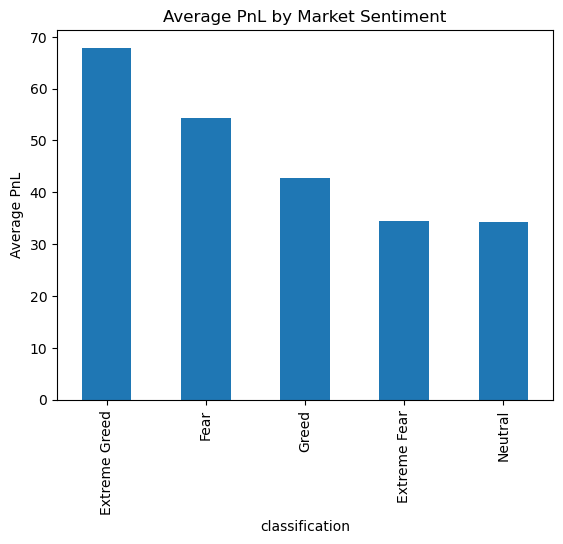

In [14]:
sentiment_pnl['mean'].plot(kind='bar')
plt.title('Average PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.show()

### Visualization 2: Trading Activity by Sentiment

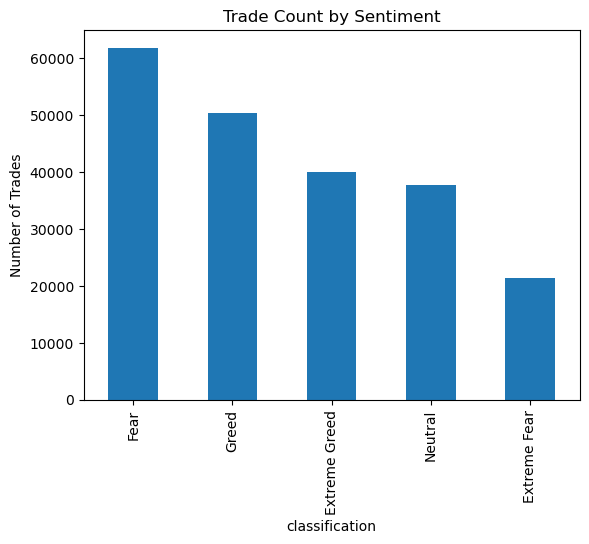

In [15]:
activity.plot(kind='bar')
plt.title('Trade Count by Sentiment')
plt.ylabel('Number of Trades')
plt.show()

### Visualization 3: BUY vs SELL Profitability Across Sentiments

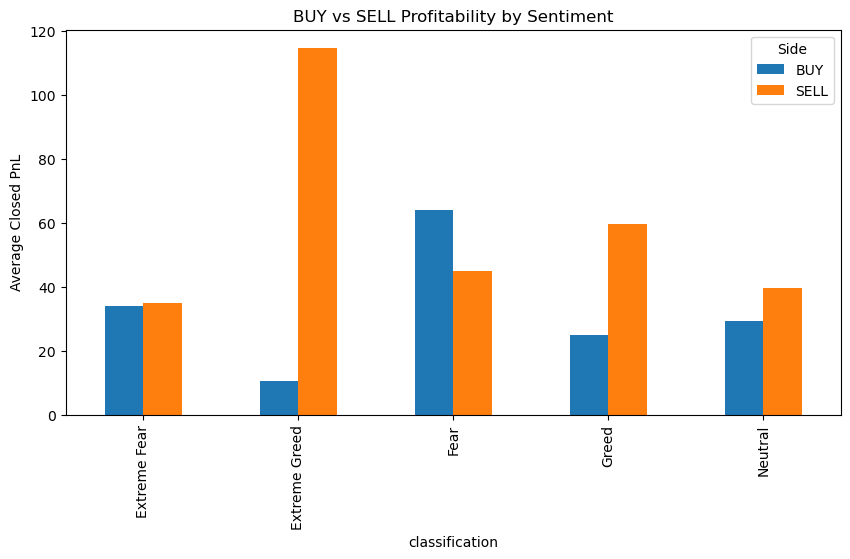

In [16]:
buy_sell.plot(kind='bar', figsize=(10,5))
plt.title('BUY vs SELL Profitability by Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

### Visualization 4: Trade Size vs Average Profitability

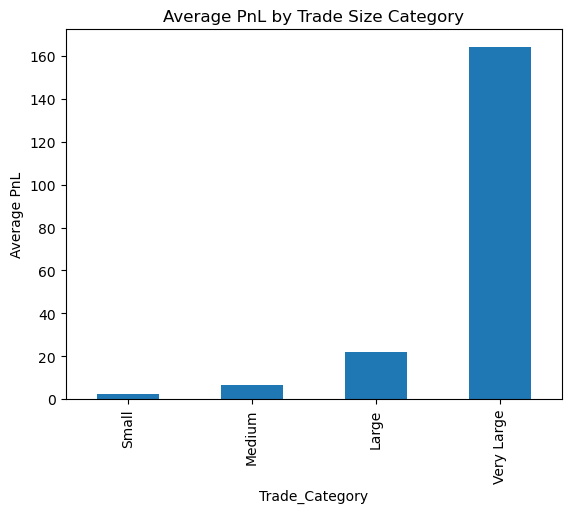

In [17]:
size_analysis['mean'].plot(kind='bar')
plt.title('Average PnL by Trade Size Category')
plt.ylabel('Average PnL')
plt.show()

### Visualization 5: PnL by Sentiment

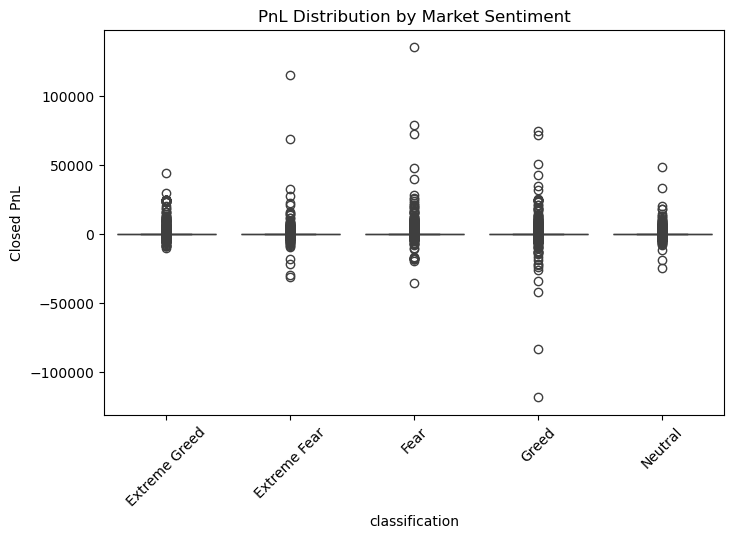

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)
plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

### Visualization 6: TRADE SIZE vs SENTIMENT HEATMAP

C:\Users\ideal\AppData\Local\Temp\ipykernel_4940\3858964532.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  trade_sentiment = pd.pivot_table(


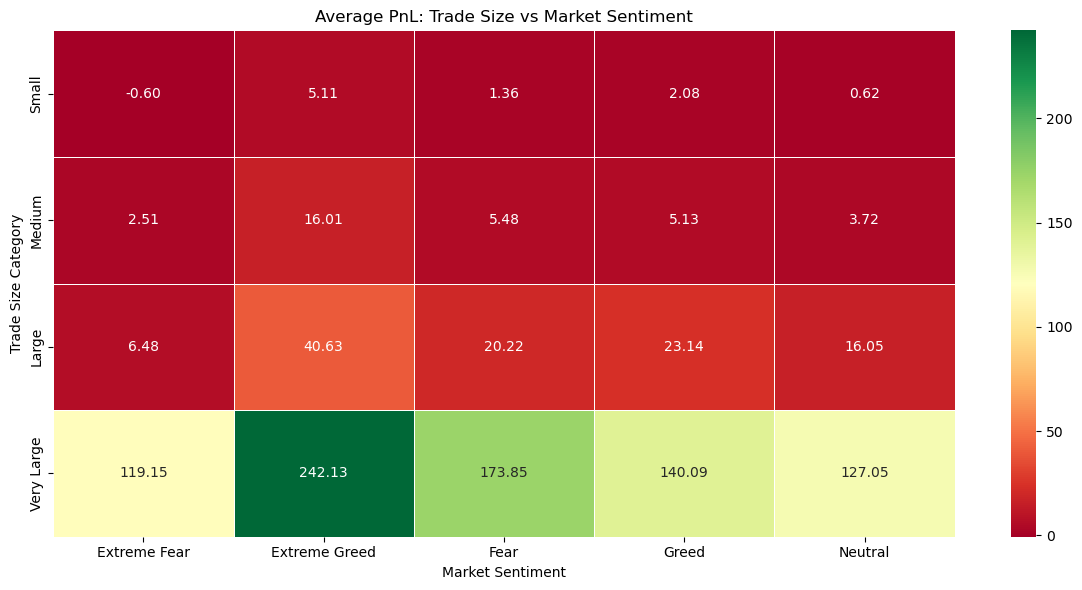

In [19]:
trade_sentiment = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='Trade_Category',
    columns='classification',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    trade_sentiment,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title('Average PnL: Trade Size vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trade Size Category')
plt.tight_layout()
plt.show()

### Visualization 7: WIN RATE PER SENTIMENT

  classification  Total_Trades  Winning_Trades    Avg_PnL  Win_Rate_%
1  Extreme Greed         39992           18594  67.892861       46.49
2           Fear         61837           26019  54.290400       42.08
4        Neutral         37686           14961  34.307718       39.70
3          Greed         50303           19358  42.743559       38.48
0   Extreme Fear         21400            7931  34.537862       37.06


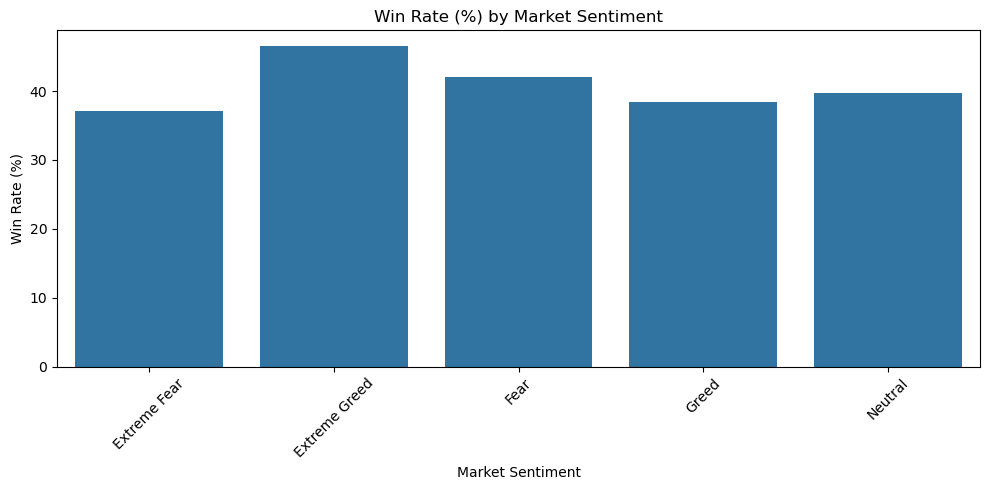

In [20]:
merged['Is_Win'] = merged['Closed PnL'] > 0

win_rate_sentiment = merged.groupby('classification').agg(
    Total_Trades=('Closed PnL', 'count'),
    Winning_Trades=('Is_Win', 'sum'),
    Avg_PnL=('Closed PnL', 'mean')
).reset_index()

win_rate_sentiment['Win_Rate_%'] = (
    win_rate_sentiment['Winning_Trades']
    / win_rate_sentiment['Total_Trades'] * 100
).round(2)

print(
    win_rate_sentiment.sort_values(
        'Win_Rate_%',
        ascending=False
    )
)

# Visualization
plt.figure(figsize=(10, 5))

sns.barplot(
    data=win_rate_sentiment,
    x='classification',
    y='Win_Rate_%'
)

plt.title('Win Rate (%) by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 8: COIN-WISE PERFORMANCE

classification  Extreme Fear  Extreme Greed    Fear   Greed  Neutral
Coin                                                                
@107                  -89.59         191.16   -2.29   86.25    52.15
BTC                     1.73          41.41   48.90   15.95    34.92
DOGE                    0.00          42.53  658.95   10.66  2969.47
ENA                   120.35          65.02  830.65   92.78  -174.72
ETH                   196.93         -20.76  236.86   98.22    46.75
HYPE                   46.90          28.10   30.06   24.57    17.32
MELANIA               218.34         -70.40   99.17   59.75    82.60
SOL                    56.01          19.72  189.47  284.80   216.70
SUI                   179.88          52.97   82.17  115.50    37.20
ZRO                     0.00          44.88   67.27  124.84  1446.90


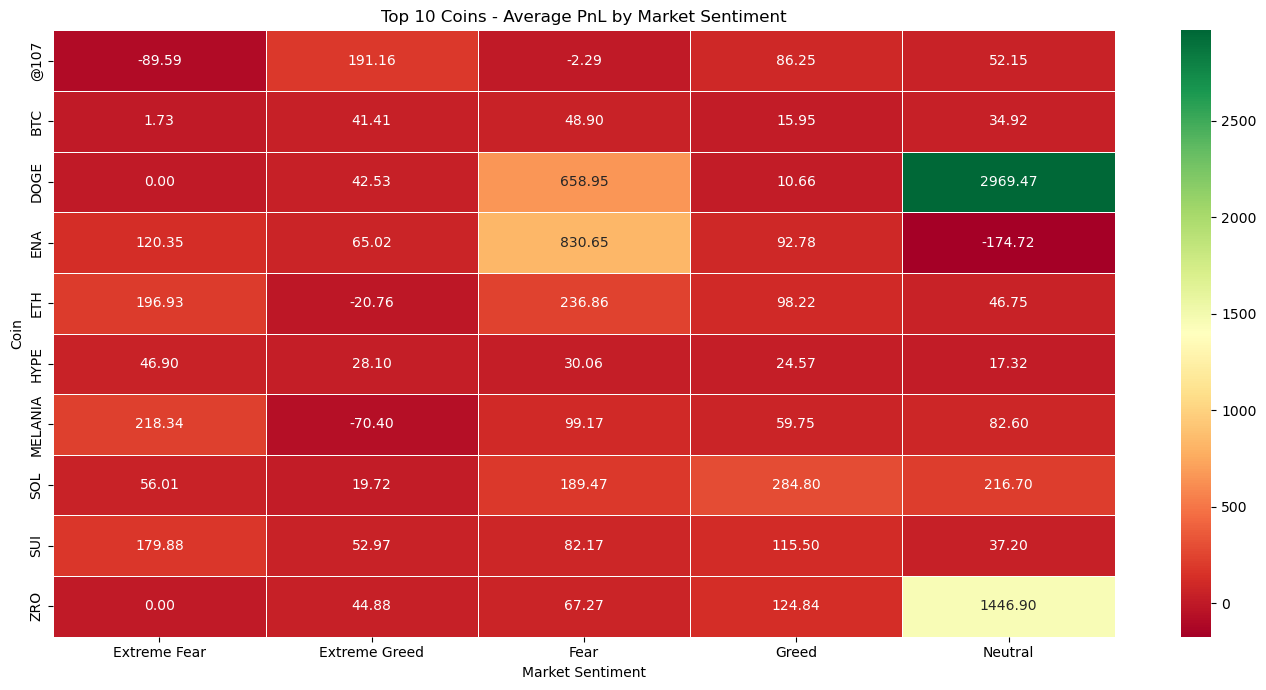

In [21]:
coin_sentiment = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='Coin',
    columns='classification',
    aggfunc='mean'
).round(2)

# Top 10 coins by total PnL
top_coins = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .nlargest(10)
    .index
)

coin_sentiment_top = coin_sentiment.loc[
    coin_sentiment.index.isin(top_coins)
]

print(coin_sentiment_top)

# Heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    coin_sentiment_top,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title('Top 10 Coins - Average PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Coin')
plt.tight_layout()
plt.show()

### Visualization 8: TIME OF DAY ANALYSIS

C:\Users\ideal\AppData\Local\Temp\ipykernel_4940\3943105345.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_analysis = merged.groupby(


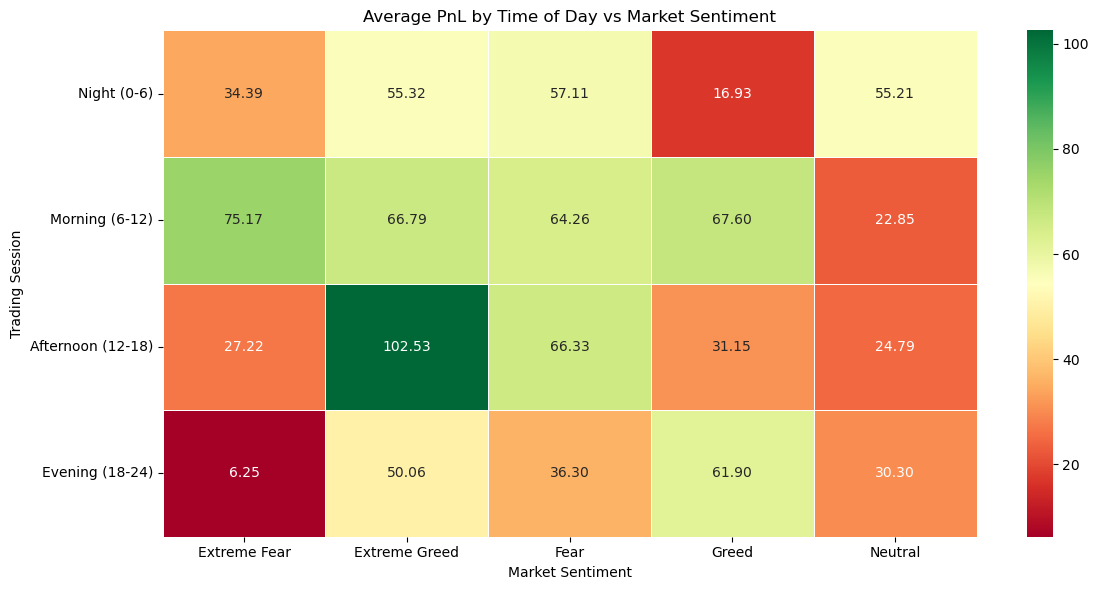

In [22]:
merged['Hour'] = pd.to_datetime(
    merged['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.hour

merged['Time_Session'] = pd.cut(
    merged['Hour'],
    bins=[0, 6, 12, 18, 24],
    labels=[
        'Night (0-6)',
        'Morning (6-12)',
        'Afternoon (12-18)',
        'Evening (18-24)'
    ],
    right=False
)

time_analysis = merged.groupby(
    ['Time_Session', 'classification']
)['Closed PnL'].mean().unstack()

plt.figure(figsize=(12, 6))

sns.heatmap(
    time_analysis,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title('Average PnL by Time of Day vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trading Session')
plt.tight_layout()
plt.show()

### Visualization 9: OUTLIER REMOVAL + CLEAN ANALYSIS

In [23]:
Q1 = merged['Closed PnL'].quantile(0.25)
Q3 = merged['Closed PnL'].quantile(0.75)
IQR = Q3 - Q1

merged_clean = merged[
    (merged['Closed PnL'] >= Q1 - 1.5 * IQR) &
    (merged['Closed PnL'] <= Q3 + 1.5 * IQR)
]

print(f"Original rows: {len(merged)}")
print(f"After outlier removal: {len(merged_clean)}")

# Clean sentiment analysis
clean_sentiment_pnl = merged_clean.groupby(
    'classification',
    observed=True
)['Closed PnL'].agg(
    Mean_PnL='mean',
    Median_PnL='median',
    Trade_Count='count'
)

print("\nClean Sentiment Analysis:")
print(clean_sentiment_pnl.sort_values('Mean_PnL', ascending=False))

Original rows: 211224
After outlier removal: 162283

Clean Sentiment Analysis:
                Mean_PnL  Median_PnL  Trade_Count
classification                                   
Extreme Greed   1.256603         0.0        30382
Fear            1.071964         0.0        48583
Neutral         0.969795         0.0        29878
Greed           0.892687         0.0        37813
Extreme Fear    0.887800         0.0        15627


# Final Conclusion and Recommendations

## Project Overview

This project analyzed the relationship between Bitcoin market sentiment and trader performance by combining Hyperliquid historical trading data with the Bitcoin Fear & Greed Index. The objective was to identify how market sentiment influences trading profitability, trade behavior, leverage usage, position sizing, and overall trader performance.

## Key Findings

### 1. Market Sentiment Influences Profitability

The analysis revealed a clear relationship between market sentiment and trading outcomes. Extreme Greed periods generated the highest average profit per trade, indicating that strong bullish sentiment often creates favorable trading opportunities. In contrast, Fear periods showed different trading dynamics, with traders exhibiting increased activity and varying profitability patterns.

### 2. Fear Periods Drive Higher Trading Activity

Fear market conditions recorded the highest number of trades, suggesting that traders become more active during uncertain market environments. This behavior indicates increased market participation as traders attempt to capitalize on volatility and price fluctuations.

### 3. Trade Direction Depends on Market Sentiment

Trading performance varied significantly based on market sentiment. BUY positions generally performed better during Fear phases, while SELL positions demonstrated stronger profitability during Greed and Extreme Greed conditions. This highlights the importance of aligning trade direction with prevailing market sentiment.

### 4. Trade Size Has a Strong Impact on Returns

Profitability increased consistently with trade size. Very Large trades generated the highest average and total profits, indicating that larger position sizes can amplify returns when supported by strong market conviction. However, larger positions also increase exposure to risk and require disciplined risk management.

### 5. Leverage and Sentiment Interact to Affect Performance

Leverage analysis showed that trading outcomes vary across leverage levels and market sentiment conditions. Moderate leverage levels generally provided a more balanced risk-reward profile, while excessive leverage increased performance volatility and downside risk.

### 6. Trader Performance Varies Across Accounts

Account-level analysis identified significant differences in profitability, win rates, and trading behavior among traders. Top-performing traders demonstrated more consistent profitability and effective adaptation to changing market sentiment conditions.

### 7. Market Timing and Asset Selection Matter

Additional analysis indicated that trading performance varies across different time periods and cryptocurrency assets. Certain trading sessions and coins consistently produced stronger average returns under specific sentiment conditions.

## Business Implications

The findings demonstrate that market sentiment has a measurable impact on trader behavior and profitability. Integrating sentiment indicators into trading strategies can help traders improve decision-making, optimize trade direction, manage leverage more effectively, and enhance overall risk management.

These insights can also support the development of sentiment-aware trading systems capable of adapting to changing market conditions and improving trading performance.

## Recommendations and Actionable Insights

### 1. Sentiment-Based Trading

* Use market sentiment as a supporting indicator for trade selection and timing.
* Focus on BUY opportunities during Fear market conditions.
* Consider profit-booking or SELL opportunities during Greed and Extreme Greed phases.

### 2. Leverage Management

* Maintain moderate leverage levels to achieve a balanced risk-reward profile.
* Avoid excessive leverage during highly volatile sentiment conditions.

### 3. Position Sizing

* Scale position sizes only when sentiment signals and trade conviction align.
* Apply strict risk controls when increasing trade exposure.

### 4. Coin Selection

* Prioritize assets that demonstrate consistent profitability across different sentiment environments.
* Avoid assets with highly unstable performance patterns.

### 5. Timing Optimization

* Monitor trading session performance and focus on time windows that historically generate stronger returns.
* Combine timing analysis with sentiment indicators for improved trade execution.

### 6. Risk Management

* Treat sentiment as one component of a broader trading framework.
* Combine sentiment analysis with position sizing, leverage control, and asset selection to improve consistency and reduce risk.

## Final Conclusion

The analysis confirms that market sentiment, trade direction, leverage, position sizing, and trader behavior collectively play a significant role in determining trading performance. By incorporating sentiment-based insights into trading decisions, traders can better adapt to market conditions, improve profitability, and manage risk more effectively. These findings provide a strong foundation for developing data-driven and sentiment-aware trading strategies in cryptocurrency markets.
